# Lorenz 96

The 5-dimensional Lorenz 96 system is

$$
\dot{x}_i = (x_{i+1} - x_{i-2})\, x_{i-1} - x_i + F, \quad i = 1, \dots, 5,
$$

where $x_{-1} = x_4$, $x_0 = x_5$, $x_6 = x_1$, with $F = 8$ generating chaotic behaviors. The ground truth is numerically integrated with the 4th-order Runge-Kutta (RK4) method with a time step of $h = 0.01$ s, and the learned models are rolled out autoregressively at the same time step.

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'eval':
    os.chdir('..')
sys.path[:0] = ['src', 'eval']
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from PIL import Image
from stats_eval import load_L96_traj, load_L96_model_Q, Eval_all_traj, plot_l96_hovmoeller

def show(*names, height=420):
    for name in names:
        im = Image.open(os.path.join(save_dir, name))
        display(im.resize((round(im.width * height / im.height), height)))

Set up output directory and load model checkpoint and test trajectory

In [2]:
# Check if the save directory exists, and create it if it doesn't
save_dir = 'figures/lorenz96'
if os.path.exists(save_dir):
    print(f'Save directory {save_dir} exists')
else:
    os.makedirs(save_dir)
    print(f'Created save directory {save_dir}')
# Load cached Lorenz 96 test trajectories and model parameters
gt_traj, Star_traj, Hat_traj = load_L96_traj('assets/models/lorenz96/L96_test_20_20000.pkl')
Q, c, x_0 = load_L96_model_Q('assets/models/lorenz96/proj/E29999.pt')
gt_flat, Star_flat, Hat_flat = gt_traj[0], Star_traj[0], Hat_traj[0]

Created save directory figures/lorenz96


Reproducing Figure 1C, the Hovmoeller plot

(20000, 5) (20000, 5) (20000, 5)


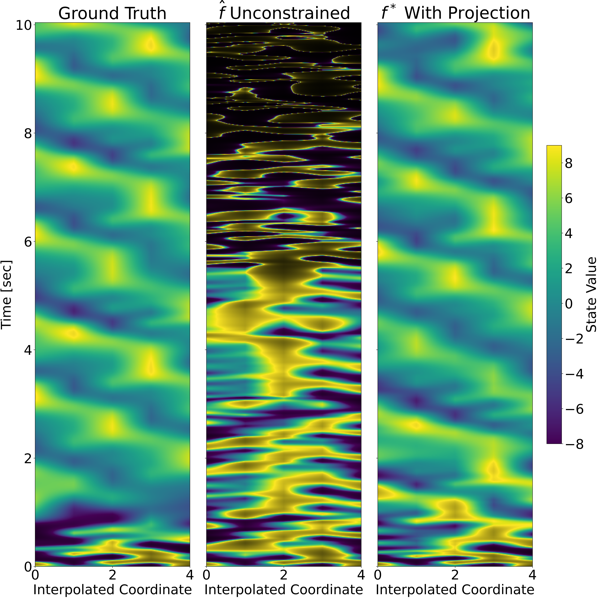

In [3]:
plot_l96_hovmoeller(gt_flat, Star_flat, Hat_flat, dt=0.01, outpath=os.path.join(save_dir, 'L96_hovmoeller.png'))
show('L96_hovmoeller.png', height=600)

Reproducing Figure 4A and B (Statistical prediction on PCA), with the KL divergence and the spectrum error.


Unstable trajectory detected. Truncating comparison to the first 2098 time steps.
Generating projected point cloud of the ellipsoid boundary...
Saved plot to figures/lorenz96/fstar_PCA_scatter.png
$f^*$ With Projection - KL Divergence: 0.6813098342384816, Jensen-Shannon Divergence: 0.29721526455165426
$\hat{f}$ Unconstrained - KL Divergence: 12.157852416897098, Jensen-Shannon Divergence: 0.7627296354194314

--- Performing Single Trajectory Fourier Evaluation ---
Spectrum Difference (GT vs. f* Projected): 0.021349
Spectrum Difference (GT vs. f̂ No Projection): 164.100704
---------------------------------
Saved Fourier spectrum plot to figures/lorenz96/fourier_spectrum.png


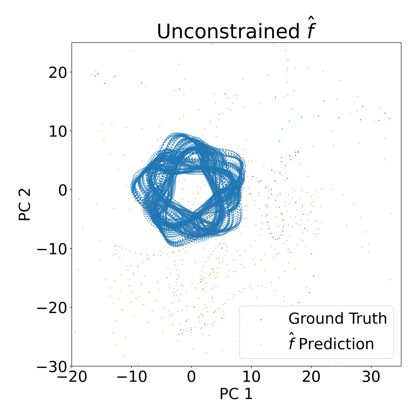

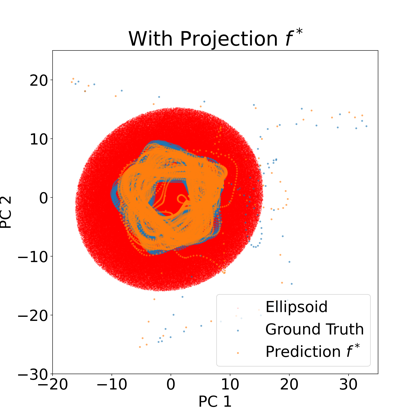

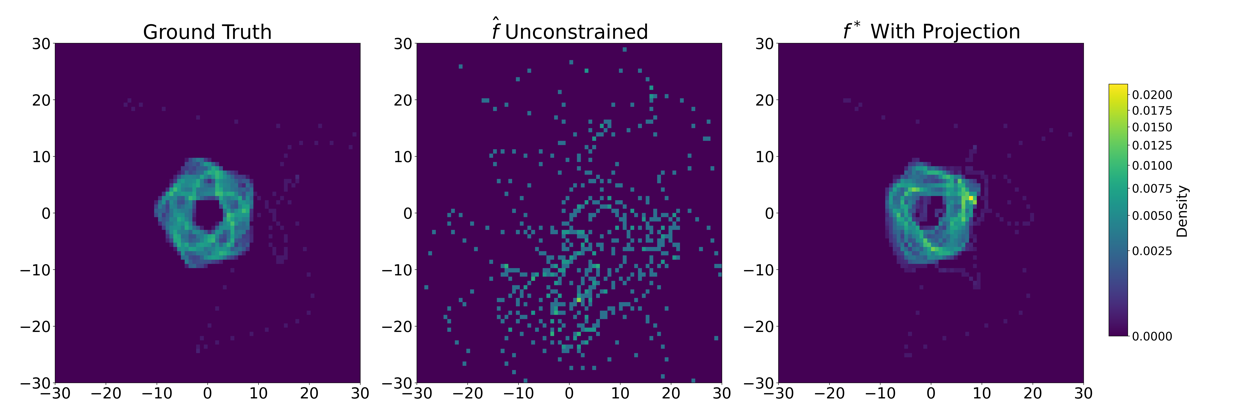

In [4]:
np.random.seed(0)
Eval_all_traj(gt_traj, Star_traj, Hat_traj, Q, c, x_0, save_dir, idx=0,
              scatter_lim=[[-20, 35], [-30, 25]], hist_lim=[[-30, 30], [-30, 30]])
show('fhat_PCA_scatter.png', 'fstar_PCA_scatter.png', 'fstar_fhat_PCA_hist.png')

Reproducing spatial and temporal spectrum comparisons (SI Appendix, Figure S1).

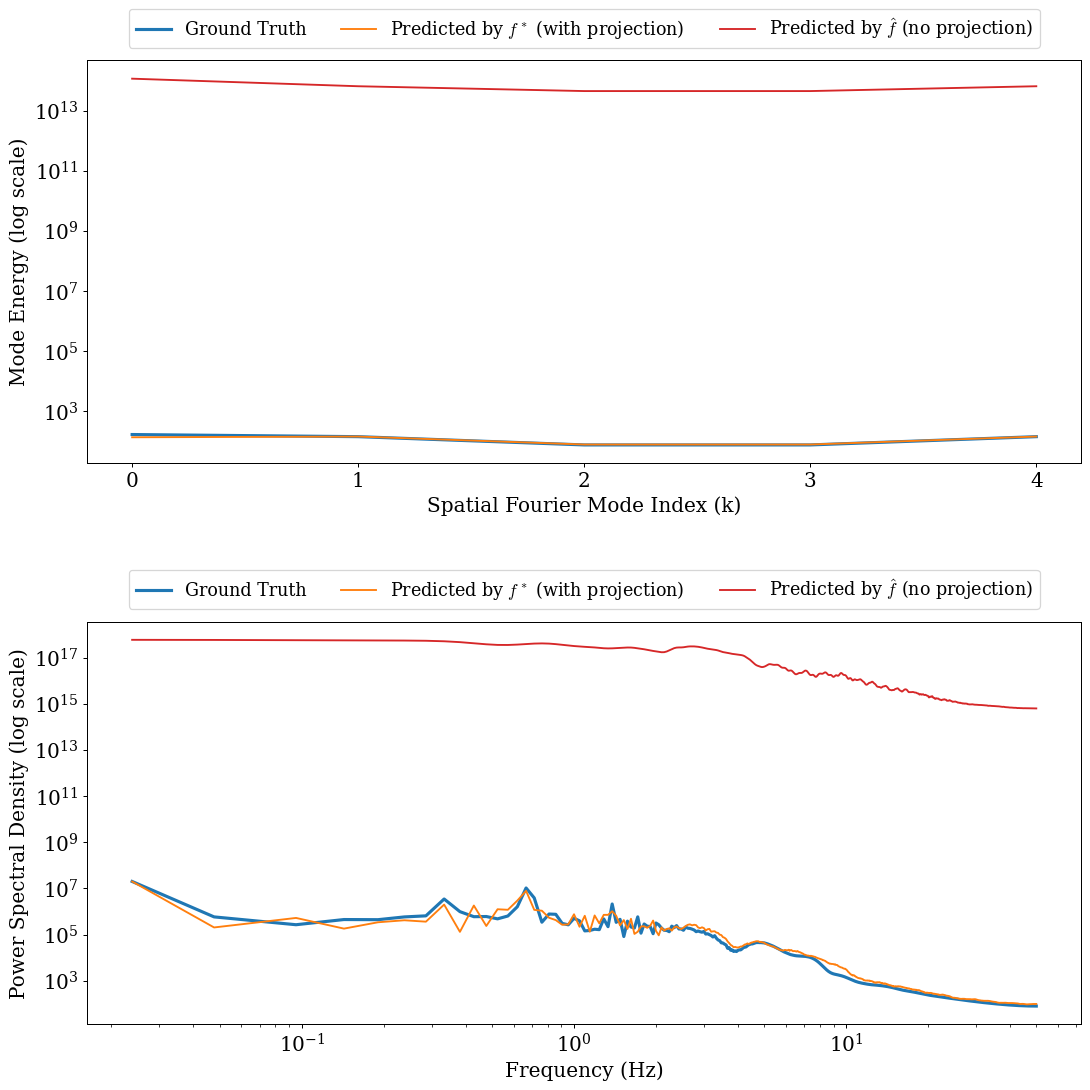

In [5]:
plt.rcdefaults()
plt.rcParams.update({'font.family': 'serif', 'mathtext.fontset': 'cm', 'font.size': 16, 'figure.dpi': 90})
labels = ('Ground Truth', r'Predicted by $f^*$ (with projection)', r'Predicted by $\hat{f}$ (no projection)')
# Filtering for length of valid trajectories (i.e., before NaN values appear)
valid_length = np.isnan(Hat_flat).any(axis=1).argmax()
trajs = [x[:valid_length] for x in (gt_flat, Star_flat, Hat_flat)]
E_k = [np.mean(np.abs(np.fft.fft(x, axis=1))**2, axis=0) for x in trajs]
PSD = [np.mean(np.abs(np.fft.fft(x, axis=0))**2, axis=1)[:valid_length // 2] for x in trajs]
freq = np.fft.fftfreq(valid_length, d=0.01)[:valid_length // 2]
freq[0] = freq[1] / 2  # so that the zero frequency can be drawn on the log axis
fig, axs = plt.subplots(2, 1, figsize=(12, 12), layout='constrained', gridspec_kw={'hspace': 0.1})
for ax, x, S in zip(axs, (np.arange(5), freq), (E_k, PSD)):
    for s, color, lw, label in zip(S, ('tab:blue', 'tab:orange', 'tab:red'), (2.5, 1.5, 1.5), labels):
        ax.plot(x, s, color=color, lw=lw, label=label)
    ax.set_yscale('log')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, fontsize=14)
axs[0].set(xlabel='Spatial Fourier Mode Index (k)', ylabel='Mode Energy (log scale)')
axs[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axs[1].set(xscale='log', xlabel='Frequency (Hz)', ylabel='Power Spectral Density (log scale)')
plt.show()

Reproducing the learned energy time history comparisons (SI Appendix, Figure S3).

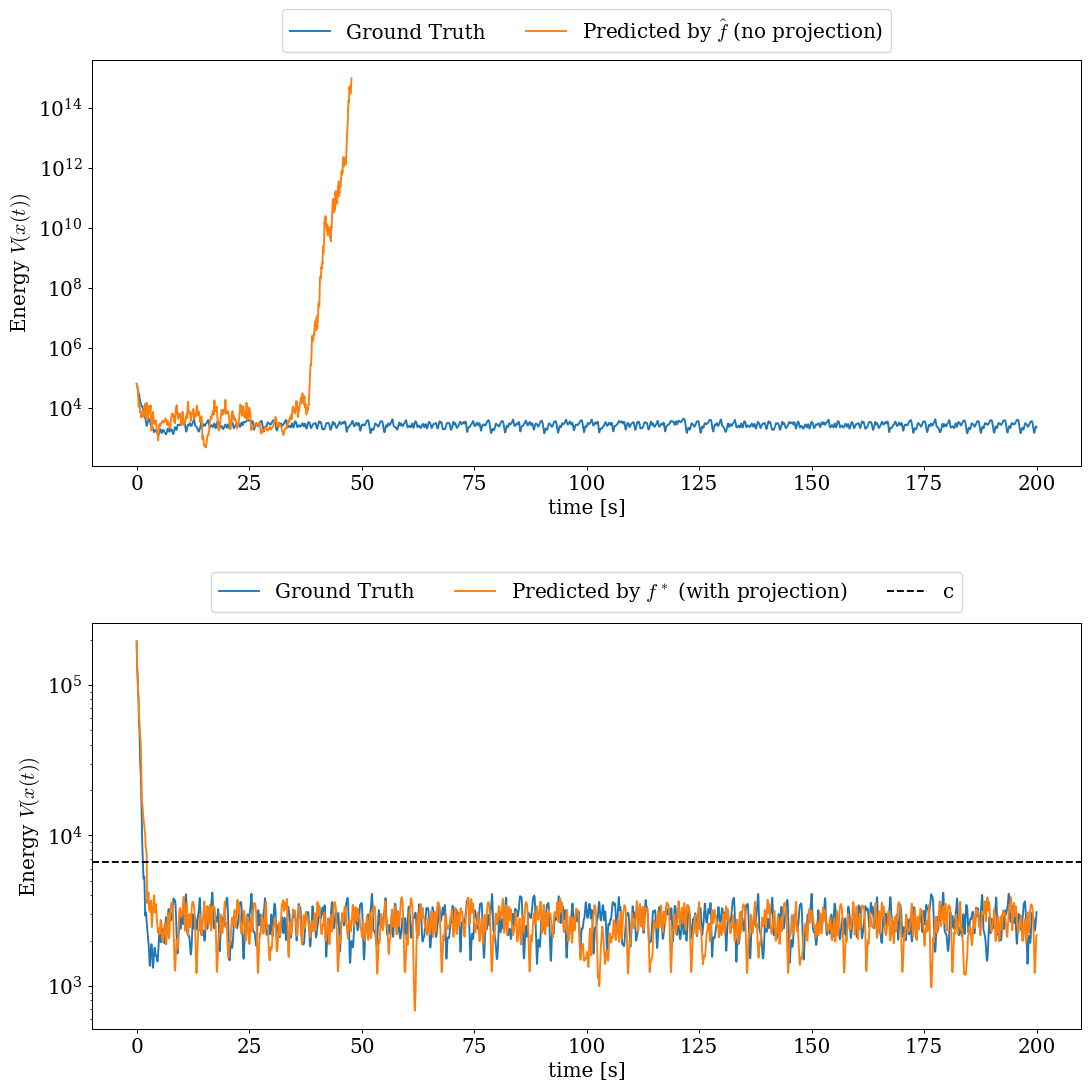

In [6]:
z = np.load('assets/models/lorenz96/L96_energy_rollouts.npz')
V = {k: np.sum((z[k] - x_0.T) @ Q * (z[k] - x_0.T), axis=1) for k in ('GT_hat', 'f_hat', 'GT', 'f_star')}
V['f_hat'][np.argmax(V['f_hat'] > 1e15):] = np.nan
t = np.arange(len(z['GT'])) * z['dt']
fig, axs = plt.subplots(2, 1, figsize=(12, 12), layout='constrained', gridspec_kw={'hspace': 0.1})
axs[0].plot(t, V['GT_hat'], label=labels[0])
axs[0].plot(t, V['f_hat'], label=labels[2])
axs[1].plot(t, V['GT'], label=labels[0])
axs[1].plot(t, V['f_star'], label=labels[1])
axs[1].axhline(c, color='black', ls='--', label='c')
for ax in axs:
    ax.set(yscale='log', xlabel='time [s]', ylabel='Energy $V(x(t))$')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)
plt.show()